<a href="https://www.kaggle.com/code/sonawanelalitsunil/abc-xyz-inventory-classification-ml-99?scriptVersionId=235769656" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/abc-xyz-inventory-classification-dataset/abc_xyz_dataset.csv


## Title: ABC-XYZ Inventory Classification Dataset

#### Description: A dataset used for categorizing inventory items based on their value (ABC analysis) and demand variability (XYZ analysis), aiding in efficient inventory management and control strategies.

## import dataset

In [2]:
df =pd.read_csv('/kaggle/input/abc-xyz-inventory-classification-dataset/abc_xyz_dataset.csv')

In [3]:
df.head()

,Item_ID,Item_Name,Category,Jan_Demand,Feb_Demand,Mar_Demand,Apr_Demand,May_Demand,Jun_Demand,Jul_Demand,Aug_Demand,Sep_Demand,Oct_Demand,Nov_Demand,Dec_Demand,Total_Annual_Units,Price_Per_Unit,Total_Sales_Value
0,ITM_001,Surface Near,Grocery,4516,4069,4664,4653,4508,4125,4669,4210,4824,4497,4259,4782,53776,10,537760
1,ITM_002,Central Him,Grocery,4792,4964,4628,4660,4897,5015,4805,4686,4896,4536,4520,5054,57453,100,5745300
2,ITM_003,Win Everyone,Apparel,61,175,38,43,15,161,224,41,387,340,70,21,1576,2,3152
3,ITM_004,Task Save,Apparel,1145,1113,717,832,783,954,1047,894,994,978,1136,712,11305,2,22610
4,ITM_005,Hotel Teacher,Grocery,1494,2051,1400,1918,1669,1733,1695,1560,1679,1381,1591,1662,19833,10,198330


In [4]:
df.tail()

,Item_ID,Item_Name,Category,Jan_Demand,Feb_Demand,Mar_Demand,Apr_Demand,May_Demand,Jun_Demand,Jul_Demand,Aug_Demand,Sep_Demand,Oct_Demand,Nov_Demand,Dec_Demand,Total_Annual_Units,Price_Per_Unit,Total_Sales_Value
995,ITM_996,No Join,Grocery,4159,4152,3776,4189,4123,4080,4306,4287,3793,3989,4183,4218,49255,2,98510
996,ITM_997,Adult Meeting,Grocery,3357,3516,3102,3329,3068,3130,3443,3473,3637,3057,3556,3021,39689,50,1984450
997,ITM_998,Agent Nature,Apparel,69,136,107,306,66,202,269,349,3,307,89,46,1949,2,3898
998,ITM_999,Follow Believe,Home & Kitchen,322,357,342,361,365,330,329,326,337,351,350,341,4111,50,205550
999,ITM_1000,Table Actually,Toys,357,378,351,362,330,352,312,337,327,299,336,331,4072,2,8144


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Item_ID             1000 non-null   object
 1   Item_Name           1000 non-null   object
 2   Category            1000 non-null   object
 3   Jan_Demand          1000 non-null   int64 
 4   Feb_Demand          1000 non-null   int64 
 5   Mar_Demand          1000 non-null   int64 
 6   Apr_Demand          1000 non-null   int64 
 7   May_Demand          1000 non-null   int64 
 8   Jun_Demand          1000 non-null   int64 
 9   Jul_Demand          1000 non-null   int64 
 10  Aug_Demand          1000 non-null   int64 
 11  Sep_Demand          1000 non-null   int64 
 12  Oct_Demand          1000 non-null   int64 
 13  Nov_Demand          1000 non-null   int64 
 14  Dec_Demand          1000 non-null   int64 
 15  Total_Annual_Units  1000 non-null   int64 
 16  Price_Per_Unit      1000 

In [6]:
df.describe()

,Jan_Demand,Feb_Demand,Mar_Demand,Apr_Demand,May_Demand,Jun_Demand,Jul_Demand,Aug_Demand,Sep_Demand,Oct_Demand,Nov_Demand,Dec_Demand,Total_Annual_Units,Price_Per_Unit,Total_Sales_Value
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1.000000e+03
mean,1418.515000,1418.394000,1421.23900,1409.242000,1411.762000,1412.853000,1410.558000,1403.721000,1411.109,1411.700000,1413.422000,1419.38100,16961.896000,57.358000,1.072288e+06
std,1489.352997,1488.076126,1496.49987,1489.280958,1488.620593,1490.568779,1497.772702,1484.283184,1482.689,1484.762652,1482.821287,1496.14098,17788.477345,155.110913,4.087477e+06
min,24.000000,7.000000,2.00000,8.000000,9.000000,15.000000,6.000000,2.000000,2.000,11.000000,9.000000,4.00000,581.000000,2.000000,1.228000e+03
25%,282.750000,279.000000,278.00000,278.000000,280.000000,277.750000,267.000000,283.000000,282.000,277.000000,275.750000,283.00000,3369.500000,2.000000,1.661900e+04
50%,539.500000,558.000000,591.50000,558.000000,541.500000,598.000000,555.000000,550.500000,547.000,591.000000,608.000000,562.00000,6737.500000,10.000000,7.283600e+04
75%,2478.500000,2529.250000,2515.75000,2427.000000,2461.250000,2451.500000,2547.500000,2407.750000,2472.750,2492.500000,2406.250000,2422.00000,29874.500000,50.000000,3.782425e+05
max,5276.000000,5171.000000,5271.00000,5186.000000,5384.000000,5462.000000,5504.000000,5219.000000,5240.000,5189.000000,5255.000000,5180.00000,59967.000000,1000.000000,5.946200e+07


In [7]:
df.isnull().sum()

Item_ID               0
Item_Name             0
Category              0
Jan_Demand            0
Feb_Demand            0
Mar_Demand            0
Apr_Demand            0
May_Demand            0
Jun_Demand            0
Jul_Demand            0
Aug_Demand            0
Sep_Demand            0
Oct_Demand            0
Nov_Demand            0
Dec_Demand            0
Total_Annual_Units    0
Price_Per_Unit        0
Total_Sales_Value     0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.shape

(1000, 18)

In [10]:
df.dtypes

Item_ID               object
Item_Name             object
Category              object
Jan_Demand             int64
Feb_Demand             int64
Mar_Demand             int64
Apr_Demand             int64
May_Demand             int64
Jun_Demand             int64
Jul_Demand             int64
Aug_Demand             int64
Sep_Demand             int64
Oct_Demand             int64
Nov_Demand             int64
Dec_Demand             int64
Total_Annual_Units     int64
Price_Per_Unit         int64
Total_Sales_Value      int64
dtype: object

In [11]:
df.columns

Index(['Item_ID', 'Item_Name', 'Category', 'Jan_Demand', 'Feb_Demand',
       'Mar_Demand', 'Apr_Demand', 'May_Demand', 'Jun_Demand', 'Jul_Demand',
       'Aug_Demand', 'Sep_Demand', 'Oct_Demand', 'Nov_Demand', 'Dec_Demand',
       'Total_Annual_Units', 'Price_Per_Unit', 'Total_Sales_Value'],
      dtype='object')

## Data visualizations

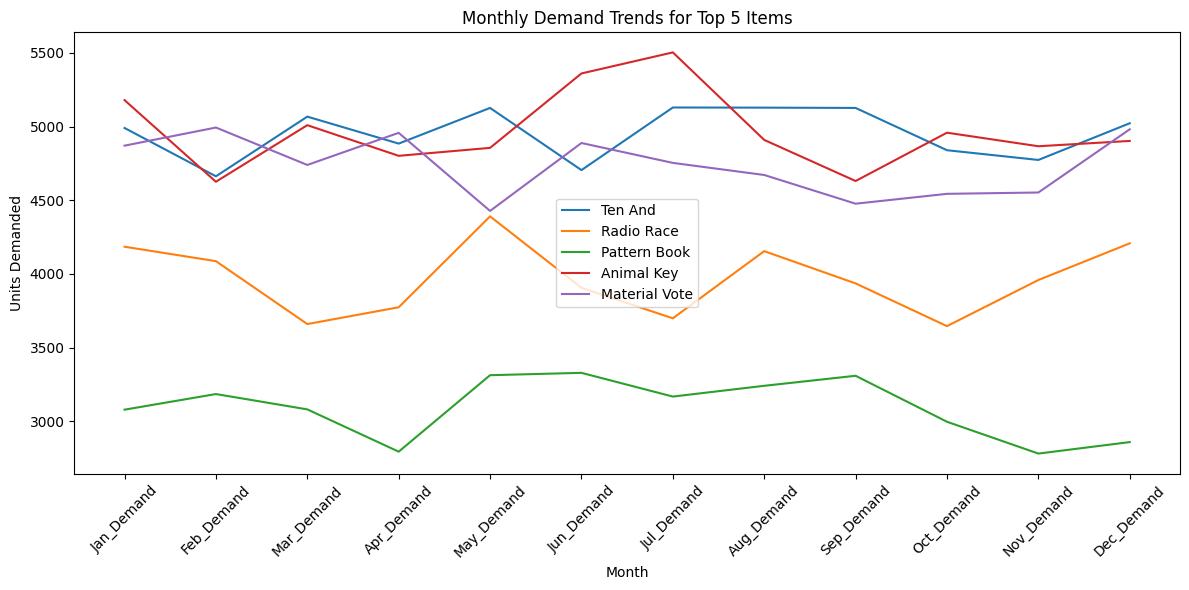

In [12]:
# Get top 5 items by Total_Sales_Value
top_items = df.nlargest(5, 'Total_Sales_Value')

# Plot demand trends
months = ['Jan_Demand', 'Feb_Demand', 'Mar_Demand', 'Apr_Demand', 'May_Demand', 
          'Jun_Demand', 'Jul_Demand', 'Aug_Demand', 'Sep_Demand', 'Oct_Demand', 
          'Nov_Demand', 'Dec_Demand']

plt.figure(figsize=(12, 6))
for _, row in top_items.iterrows():
    plt.plot(months, row[months], label=row['Item_Name'])

plt.title('Monthly Demand Trends for Top 5 Items')
plt.xlabel('Month')
plt.ylabel('Units Demanded')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

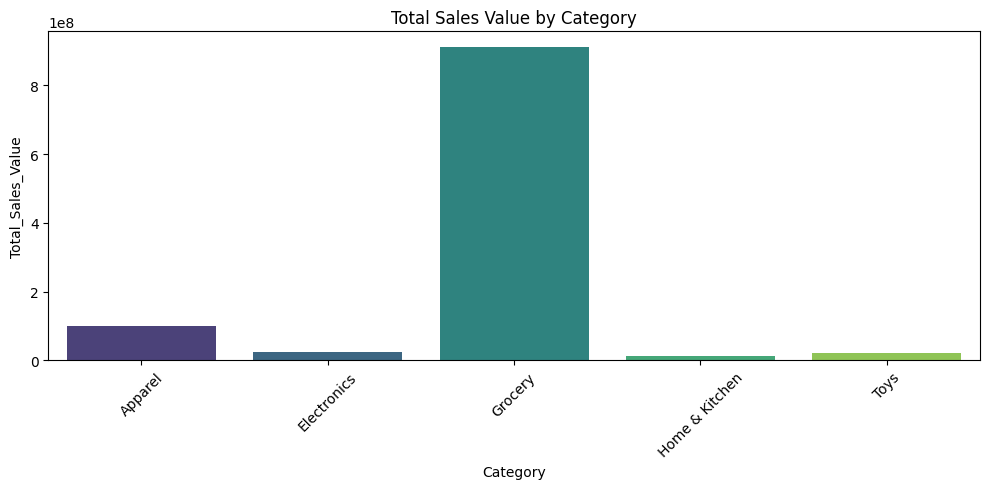

In [13]:
category_sales = df.groupby('Category')['Total_Sales_Value'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=category_sales, x='Category', y='Total_Sales_Value', palette='viridis')
plt.title('Total Sales Value by Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


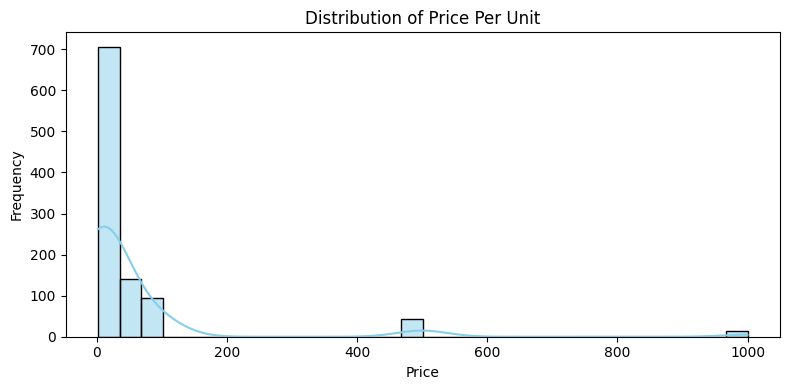

In [14]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Price_Per_Unit'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Price Per Unit')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()



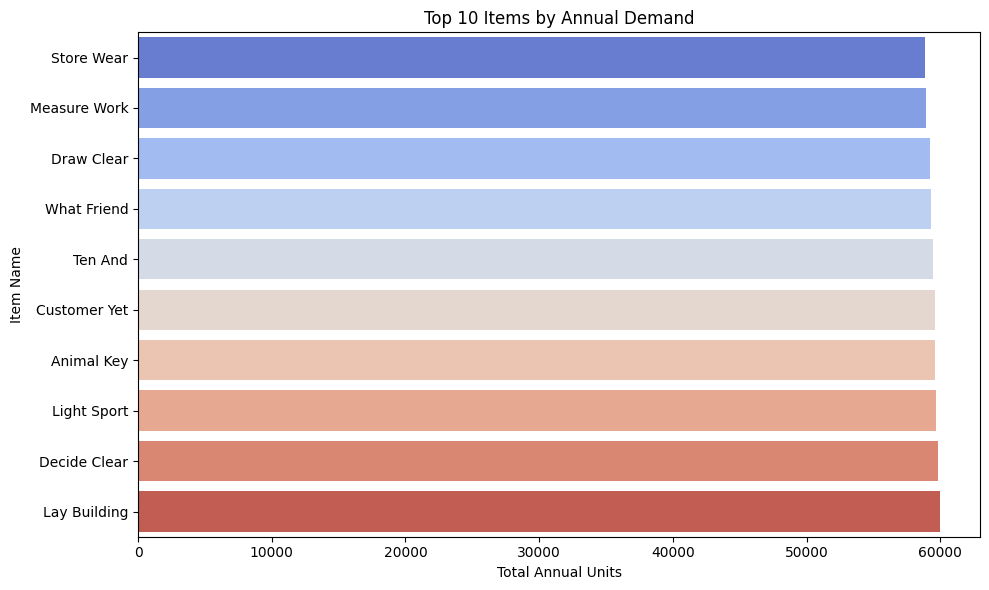

In [15]:
top_demand = df.nlargest(10, 'Total_Annual_Units').sort_values('Total_Annual_Units')

plt.figure(figsize=(10, 6))
sns.barplot(x='Total_Annual_Units', y='Item_Name', data=top_demand, palette='coolwarm')
plt.title('Top 10 Items by Annual Demand')
plt.xlabel('Total Annual Units')
plt.ylabel('Item Name')
plt.tight_layout()
plt.show()


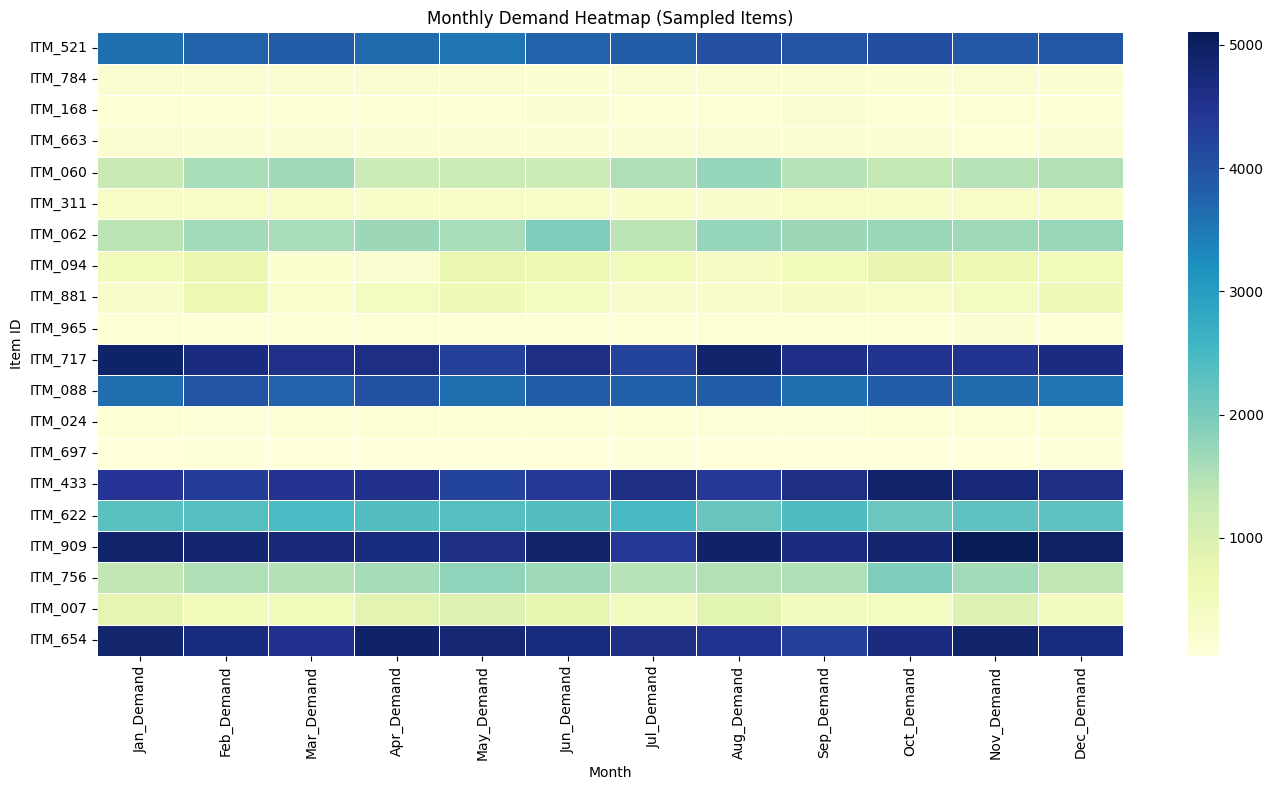

In [16]:
monthly_data = df.set_index('Item_ID')[months]

plt.figure(figsize=(14, 8))
sns.heatmap(monthly_data.sample(20), cmap='YlGnBu', linewidths=0.5)  # show sample of 20 items
plt.title('Monthly Demand Heatmap (Sampled Items)')
plt.xlabel('Month')
plt.ylabel('Item ID')
plt.tight_layout()
plt.show()


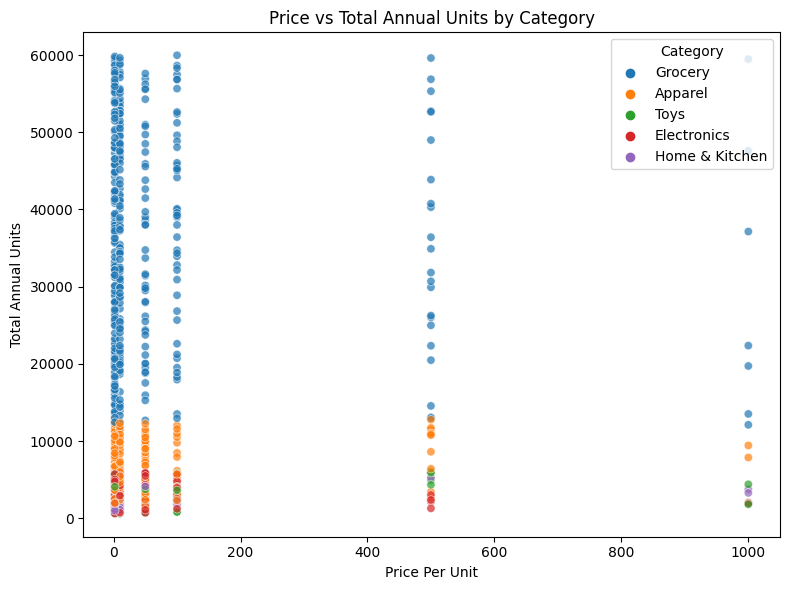

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Price_Per_Unit', y='Total_Annual_Units', hue='Category', alpha=0.7)
plt.title('Price vs Total Annual Units by Category')
plt.xlabel('Price Per Unit')
plt.ylabel('Total Annual Units')
plt.tight_layout()
plt.show()


## Predictive modeling

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [19]:
df['ABC_Class'] = pd.qcut(df['Total_Sales_Value'], q=[0, 0.7, 0.9, 1.0], labels=['A', 'B', 'C'])

# Step 2: Encode target variable
le = LabelEncoder()
df['ABC_Class_Code'] = le.fit_transform(df['ABC_Class'])  # A:0, B:1, C:2


In [20]:
# Step 3: Select features
feature_cols = ['Jan_Demand', 'Feb_Demand', 'Mar_Demand', 'Apr_Demand', 'May_Demand', 
                'Jun_Demand', 'Jul_Demand', 'Aug_Demand', 'Sep_Demand', 'Oct_Demand', 
                'Nov_Demand', 'Dec_Demand', 'Price_Per_Unit', 'Total_Annual_Units']

X = df[feature_cols]
y = df['ABC_Class_Code']

In [21]:
# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
# Step 6: Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM (RBF Kernel)': SVC(kernel='rbf')
}


🔹 Logistic Regression
Accuracy: 82.50%


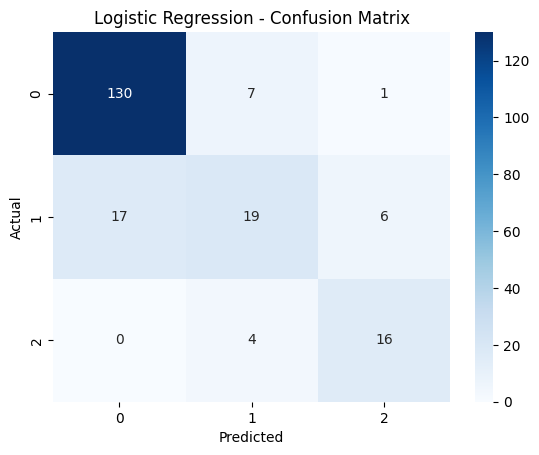


🔹 K-Nearest Neighbors
Accuracy: 83.50%


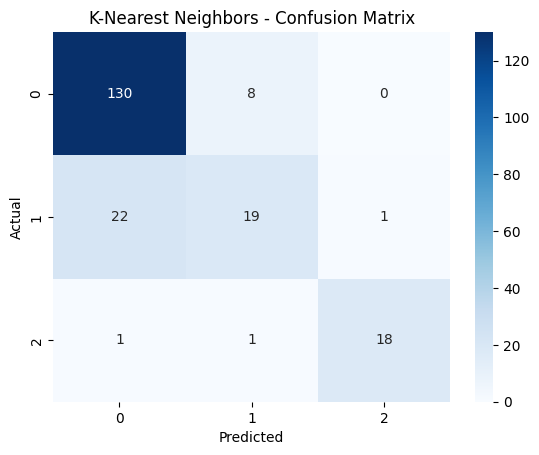


🔹 Decision Tree
Accuracy: 99.00%


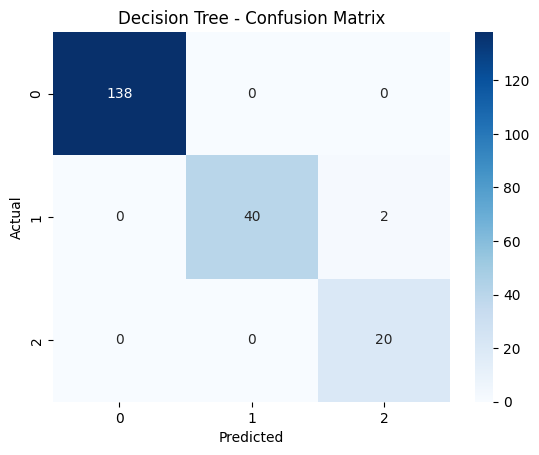


🔹 Random Forest
Accuracy: 98.50%


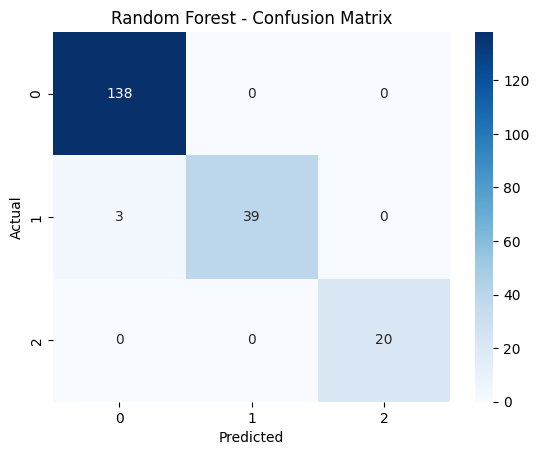


🔹 SVM (RBF Kernel)
Accuracy: 80.50%


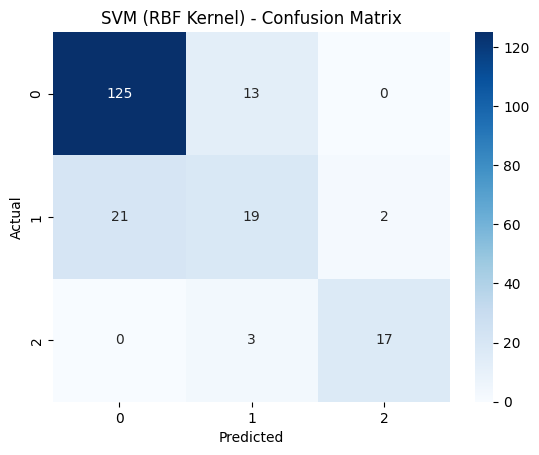

In [23]:
# Step 7: Train, predict, evaluate
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred) * 100
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n🔹 {name}")
    print(f"Accuracy: {acc:.2f}%")
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

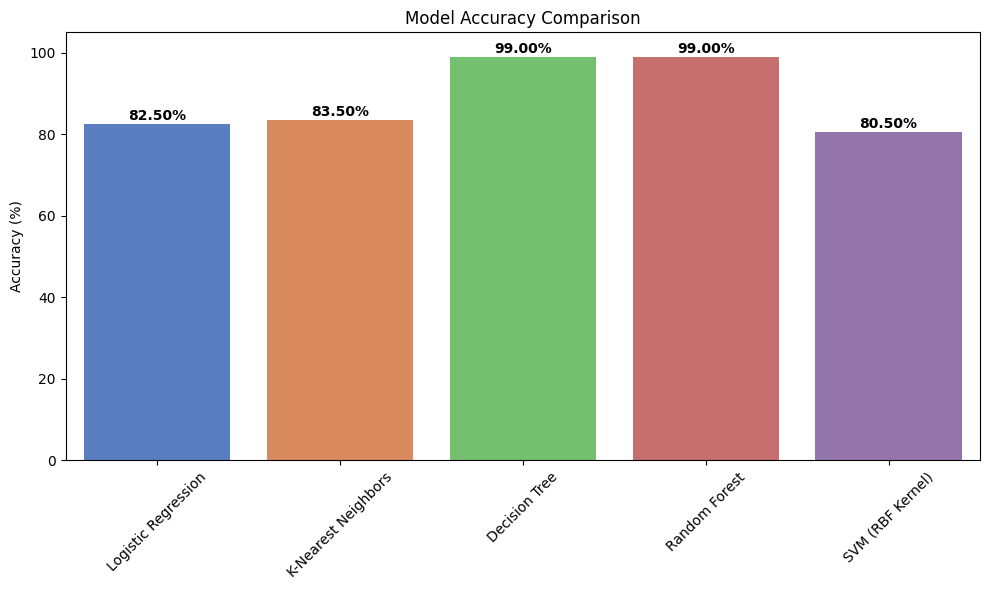

In [24]:
# Model accuracy results
accuracy_dict = {
    'Logistic Regression': 82.50,
    'K-Nearest Neighbors': 83.50,
    'Decision Tree': 99.00,
    'Random Forest': 99.00,
    'SVM (RBF Kernel)': 80.50
}

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=list(accuracy_dict.keys()), y=list(accuracy_dict.values()), palette='muted')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 105)
plt.xticks(rotation=45)

# Add percentage labels on bars
for i, acc in enumerate(accuracy_dict.values()):
    plt.text(i, acc + 1, f'{acc:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## THank you..pls upvote!!!!